<a href="https://colab.research.google.com/github/sofia-seo-j/chantey_2026/blob/AIDM/EX1.5_Shallow_Regression_with_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Goal**: Predict the number of bikes rented in Seoul

# Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Read data
- *parse_dates = [0]* indicates that the first column contains the date
- *date_format* can be used to inform the parser about the format
- *rename* can be used to rename columns and rows

In [2]:
data = (pd.read_csv('https://www.dropbox.com/scl/fi/zesyfb1f56wuju2s9a93i/SeoulBikeData.csv?rlkey=7iv696j46qhog6jwye72gwpe7&dl=1', parse_dates = [0], date_format = '%d/%m/%Y')
    .rename(columns = {'Date':'date', 'Rented Bike Count':'count', 'Hour':'hour', 'Temperature(°C)': 'temp',
    'Humidity(%)': 'humidity', 'Wind speed (m/s)': 'wind speed', 'Visibility (10m)':'visibility', 'Dew point temperature(°C)':'dew point',
    'Solar Radiation (MJ/m2)': 'solar radiation', 'Rainfall(mm)': 'rain', 'Snowfall (cm)':'snow', 'Seasons':'season', 'Holiday':'holiday', 'Functioning Day':'workingday'})
)

# Get a first impression of the data
The data consists of one row per hour. Columns include the date, the number of rented bikes (count), weather conditions, as well as auxiliary calendar variables (season, holiday, etc).

In [3]:
data.head()

,date,count,hour,temp,humidity,wind speed,visibility,dew point,solar radiation,rain,snow,season,holiday,workingday
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
data.tail()

,date,count,hour,temp,humidity,wind speed,visibility,dew point,solar radiation,rain,snow,season,holiday,workingday
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,2018-11-30,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [5]:
data.dtypes

,0
date,datetime64[ns]
count,int64
hour,int64
temp,float64
humidity,int64
wind speed,float64
visibility,int64
dew point,float64
solar radiation,float64
rain,float64


In [6]:
data.describe() # get descriptive statistics of the numeric variables

,date,count,hour,temp,humidity,wind speed,visibility,dew point,solar radiation,rain,snow
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2018-05-31 23:59:59.999999744,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746


### Plot some histograms of all numeric variables excluding date and hour
**Hint**: the *drop* method can be used to drop columns but it only overwrites the original dataframe if *inplace = true* is used. Otherwise it returns the transformed df.

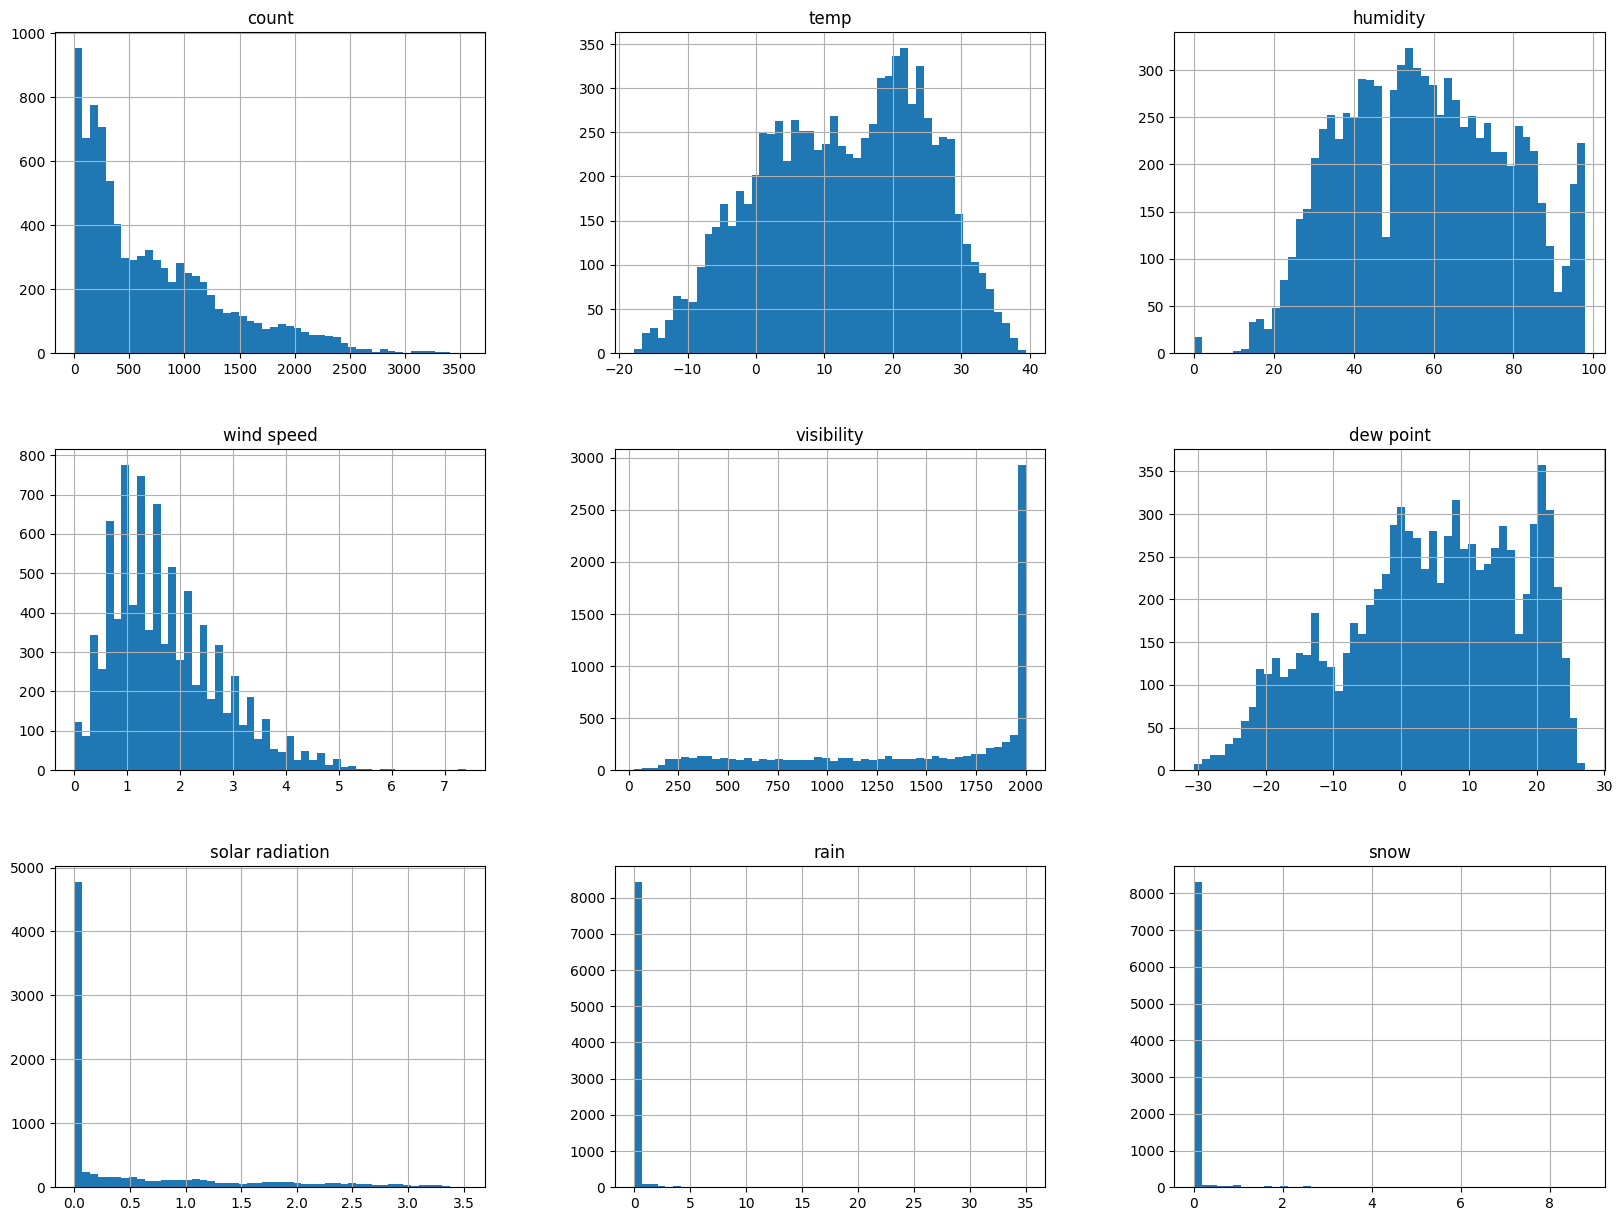

In [7]:
data.drop(["date", "hour"], axis = 1).hist(bins = 50, figsize = (20, 15))
plt.show()

<Axes: >

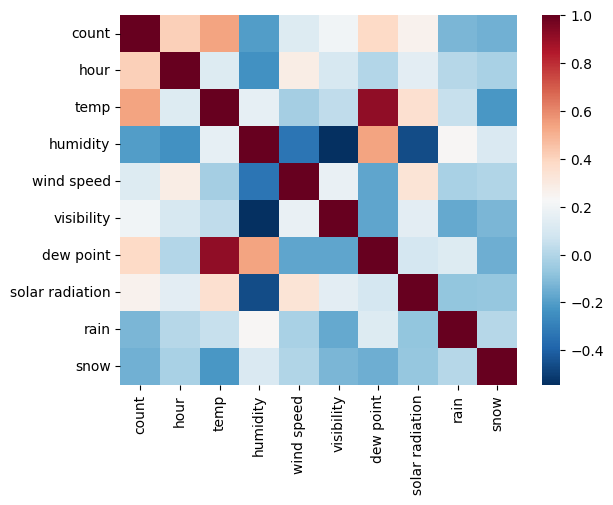

In [8]:
import seaborn as sns
sns.heatmap(data.select_dtypes(include=['number']).corr(),
    xticklabels=data.select_dtypes(include=['number']).columns,
    yticklabels=data.select_dtypes(include=['number']).columns,
    cmap='RdBu_r')

# Set aside a test sample


## Pre-process data

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical features
categorical_features = data.select_dtypes(include=['object']).columns
numerical_features = data.select_dtypes(include=['number', 'datetime64[ns]']).columns # Include datetime just in case, though it should be dropped or handled separately for NN

# Remove 'date' and 'hour' from numerical features if they are not intended for direct use in NN
# For this NN exercise, we'll exclude 'date' as it's a datetime object and 'hour' can be treated numerically.
# Let's consider 'hour' as a numerical feature for now, or convert it to categorical if needed.
# For simplicity, let's just drop 'date' and assume 'hour' is numerical.
numerical_features = numerical_features.drop('date', errors='ignore') # remove 'date' if present


# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

### Split the data into training and test sets

In [10]:
from sklearn.model_selection import train_test_split

training_data, test_data = train_test_split(data, random_state = 42, test_size = 0.2)
training_data_response = training_data[["count"]]
training_data_features = training_data.drop(["count", "date"], axis = 1)
test_data_response = test_data[["count"]]
test_data_features = test_data.drop(["count", "date"], axis = 1)

# preprocess data
training_data_features = preprocessor.fit_transform(training_data_features)
test_data_features = preprocessor.transform(test_data_features)

# Exercise: Find best shallow NN and compare to LASSO
1. Do k-fold cross validation for shallow feedforward NN finding the optimal number of neurons in the hidden layer.
2. Use LASSO regression as a benchmark where the optimal regularization parameter is computed using k-fold cross validation.
3. Compare the two methods with optimal parameters on the test data using root means squared error as a loss function.

## Fit Shallow Neural Network

In [11]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

# Fit a shallow NN with ReLU activations and find the best number of hidden nodes using k-fold CV
nn = MLPRegressor(solver='adam', activation='relu', random_state=42, max_iter=500)

# Define parameter grid for hidden layer sizes
# We will test single hidden layer with various number of neurons
param_grid = {
    'hidden_layer_sizes': [(s,) for s in range(5, 101, 5)] # Example: (10,), (20,), ..., (100,)
}

best_nn = GridSearchCV(nn, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
best_nn.fit(training_data_features, training_data_response.values.ravel())

print("Best parameters for NN:", best_nn.best_params_)
print("Best cross-validation RMSE for NN:", np.sqrt(-best_nn.best_score_))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for NN: {'hidden_layer_sizes': (90,)}
Best cross-validation RMSE for NN: 363.6633200041445


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


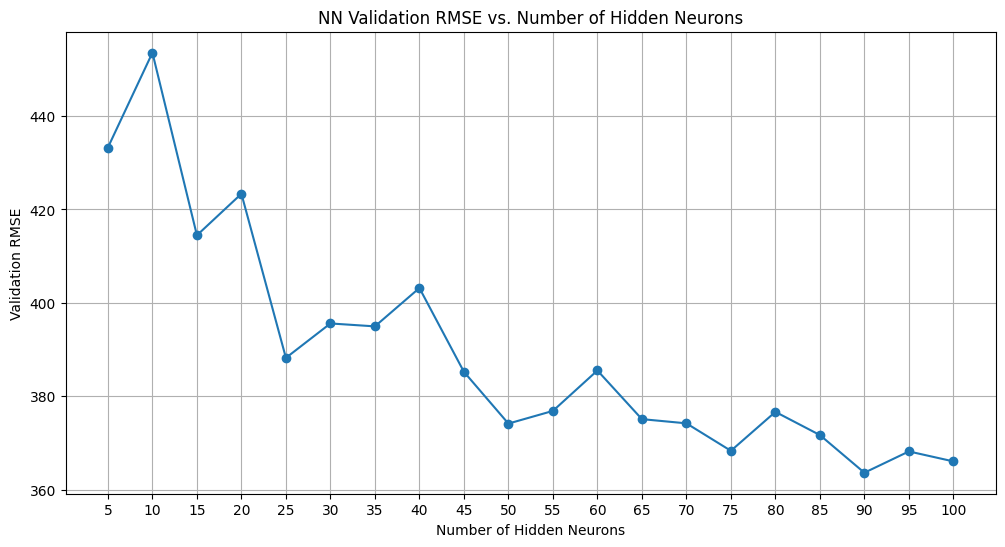

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting NN validation error
nn_results = pd.DataFrame(best_nn.cv_results_)
nn_results['mean_test_rmse'] = np.sqrt(-nn_results['mean_test_score'])

plt.figure(figsize=(12, 6))
plt.plot(nn_results['param_hidden_layer_sizes'].apply(lambda x: x[0]), nn_results['mean_test_rmse'], marker='o')
plt.title('NN Validation RMSE vs. Number of Hidden Neurons')
plt.xlabel('Number of Hidden Neurons')
plt.ylabel('Validation RMSE')
plt.grid(True)
plt.xticks(nn_results['param_hidden_layer_sizes'].apply(lambda x: x[0]))
plt.show()


## Estimate a LASSO regression model

In [13]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import numpy as np

# Estimate a LASSO regression model with cross-validation for the regularization parameter
lasso = Lasso(max_iter=2000, random_state=42)

# Define parameter grid for alpha (regularization strength)
# It's common to search over a logarithmic scale for alpha
param_grid_lasso = {
    'alpha': np.logspace(-4, 0, 50) # Example: search from 0.0001 to 1.0
}

best_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
best_lasso.fit(training_data_features, training_data_response.values.ravel())

print("Best parameters for LASSO:", best_lasso.best_params_)
print("Best cross-validation RMSE for LASSO:", np.sqrt(-best_lasso.best_score_))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters for LASSO: {'alpha': np.float64(0.013257113655901081)}
Best cross-validation RMSE for LASSO: 431.54111374732054


## Test both models on the test data and compare fit

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Ensure test_data_features is preprocessed for the models
# This assumes 'preprocessor' and 'test_data_features' are correctly defined and populated from previous steps.
# If 'test_data_features' is already preprocessed (as expected after 'sUiD92xvBkdj'), then no further preprocessing is needed here.

# Get predictions from the best NN model on the test data
# Note: best_nn.best_estimator_ holds the trained model with optimal parameters
nn_predictions = best_nn.best_estimator_.predict(test_data_features)
nn_rmse = np.sqrt(mean_squared_error(test_data_response, nn_predictions))

# Get predictions from the best LASSO model on the test data
# Note: best_lasso.best_estimator_ holds the trained model with optimal parameters
lasso_predictions = best_lasso.best_estimator_.predict(test_data_features)
lasso_rmse = np.sqrt(mean_squared_error(test_data_response, lasso_predictions))

print(f"Neural Network Test RMSE: {nn_rmse:.2f}")
print(f"LASSO Test RMSE: {lasso_rmse:.2f}")

# Compare the results
if nn_rmse < lasso_rmse:
    print(f"The Neural Network performed better on the test data with an RMSE of {nn_rmse:.2f} compared to LASSO's {lasso_rmse:.2f}.")
elif lasso_rmse < nn_rmse:
    print(f"The LASSO model performed better on the test data with an RMSE of {lasso_rmse:.2f} compared to NN's {nn_rmse:.2f}.")
else:
    print("Both models performed equally well on the test data.")


Neural Network Test RMSE: 381.19
LASSO Test RMSE: 440.78
The Neural Network performed better on the test data with an RMSE of 381.19 compared to LASSO's 440.78.
